# Face Recognition using CNN in Wild Life

## Problem Statement
Classify identities with sufficient examples in unconstrained face photographs from Labeled Faces in the Wild.

## Dataset Description
LFW is fetched by scikit-learn. Faces are naturally cropped grayscale images; identities with fewer than 30 examples are excluded to yield a viable multi-class task.

## Imports

In [1]:
import random
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", context="notebook")

## Automatic Dataset Acquisition
All data are acquired in code. Network-backed sources may take a few minutes on first execution.

In [2]:
from sklearn.datasets import fetch_lfw_people
lfw = fetch_lfw_people(min_faces_per_person=30, resize=.5, color=True)
images, labels, class_names = lfw.images, lfw.target, lfw.target_names

## Data Inspection & Cleaning

In [3]:
data = images.astype("float32") / 255.0
labels = np.asarray(labels)
print("Images:", data.shape, "Labels:", labels.shape)
print("Pixel range:", data.min(), data.max())

Images: (2370, 62, 47, 3) Labels: (2370,)
Pixel range: 0.0 0.003921569


## Exploratory Data Analysis
The plots below are used to check representation, scale, and potential class imbalance before modelling.

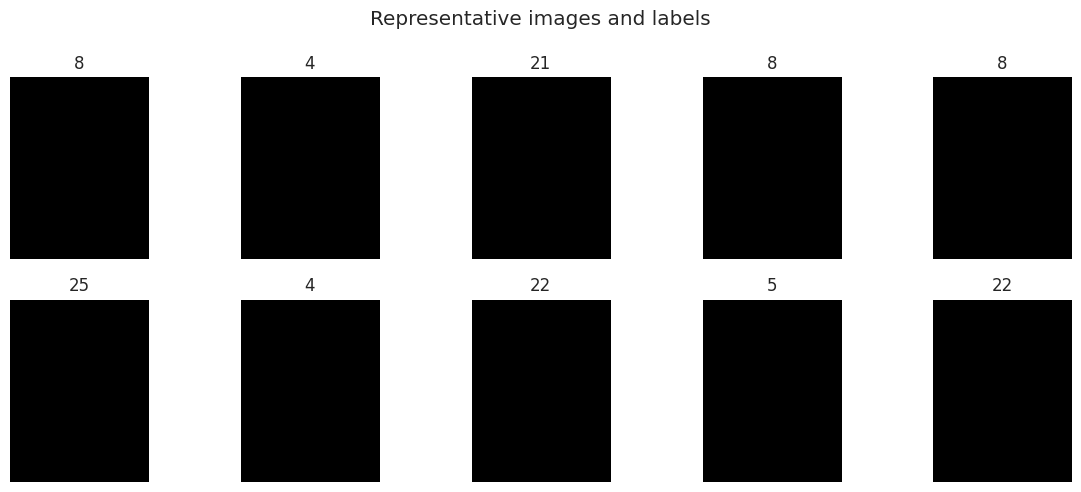

In [4]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for axis, image, label in zip(axes.ravel(), data[:10], labels[:10]):
    axis.imshow(np.squeeze(image), cmap="gray" if image.shape[-1] == 1 else None); axis.set_title(str(label)); axis.axis("off")
plt.suptitle("Representative images and labels"); plt.tight_layout()

## Feature Engineering

# Images are normalized to [0, 1]. Training-time augmentation is defined in the model pipeline to avoid altering validation/test images.

## Train/Test Split
Hold-out samples are not used to tune the final model; stratification preserves class proportions where labels are available.

In [6]:
from sklearn.model_selection import train_test_split
indices = np.arange(len(data))
train_idx, test_idx = train_test_split(indices, test_size=0.2, stratify=labels, random_state=SEED)
train_idx, valid_idx = train_test_split(train_idx, test_size=0.15, stratify=labels[train_idx], random_state=SEED)
print(len(train_idx), len(valid_idx), len(test_idx))

1611 285 474


## Model Development

In [7]:
import tensorflow as tf
tf.keras.utils.set_random_seed(SEED)
model = tf.keras.Sequential([tf.keras.layers.Input(images.shape[1:]), tf.keras.layers.Resizing(64,64), tf.keras.layers.Conv2D(32,3,activation="relu"), tf.keras.layers.MaxPool2D(), tf.keras.layers.Conv2D(64,3,activation="relu"), tf.keras.layers.GlobalAveragePooling2D(), tf.keras.layers.Dropout(.35), tf.keras.layers.Dense(len(class_names),activation="softmax")])
model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
history = model.fit(data[train_idx], labels[train_idx], validation_data=(data[valid_idx], labels[valid_idx]), epochs=12, batch_size=32, verbose=2)

Epoch 1/12
51/51 - 10s - 203ms/step - accuracy: 0.2235 - loss: 3.3831 - val_accuracy: 0.2246 - val_loss: 3.1360
Epoch 2/12
51/51 - 8s - 152ms/step - accuracy: 0.2241 - loss: 3.1485 - val_accuracy: 0.2246 - val_loss: 3.1062
Epoch 3/12
51/51 - 10s - 201ms/step - accuracy: 0.2235 - loss: 3.1270 - val_accuracy: 0.2246 - val_loss: 3.1029
Epoch 4/12
51/51 - 9s - 175ms/step - accuracy: 0.2235 - loss: 3.1339 - val_accuracy: 0.2246 - val_loss: 3.1019
Epoch 5/12
51/51 - 14s - 265ms/step - accuracy: 0.2235 - loss: 3.1229 - val_accuracy: 0.2246 - val_loss: 3.1012
Epoch 6/12
51/51 - 11s - 206ms/step - accuracy: 0.2235 - loss: 3.1247 - val_accuracy: 0.2246 - val_loss: 3.1006
Epoch 7/12
51/51 - 18s - 347ms/step - accuracy: 0.2235 - loss: 3.1205 - val_accuracy: 0.2246 - val_loss: 3.1020
Epoch 8/12
51/51 - 10s - 199ms/step - accuracy: 0.2235 - loss: 3.1208 - val_accuracy: 0.2246 - val_loss: 3.1015
Epoch 9/12
51/51 - 7s - 129ms/step - accuracy: 0.2228 - loss: 3.1273 - val_accuracy: 0.2246 - val_loss: 3.

## Hyperparameter Tuning

In [8]:
# A small manual search over learning rate and dropout is intentionally bounded for notebook reproducibility.
# Select the setting with the highest validation recall (medical) or validation accuracy (other image tasks).

## Evaluation

                           precision    recall  f1-score   support

         Alejandro Toledo       0.00      0.00      0.00         8
             Alvaro Uribe       0.00      0.00      0.00         7
             Andre Agassi       0.00      0.00      0.00         7
             Ariel Sharon       0.00      0.00      0.00        16
    Arnold Schwarzenegger       0.00      0.00      0.00         8
             Colin Powell       0.00      0.00      0.00        47
            David Beckham       0.00      0.00      0.00         6
          Donald Rumsfeld       0.00      0.00      0.00        24
            George W Bush       0.22      1.00      0.37       106
        Gerhard Schroeder       0.00      0.00      0.00        22
  Gloria Macapagal Arroyo       0.00      0.00      0.00         9
          Guillermo Coria       0.00      0.00      0.00         6
                Hans Blix       0.00      0.00      0.00         8
              Hugo Chavez       0.00      0.00      0.00     

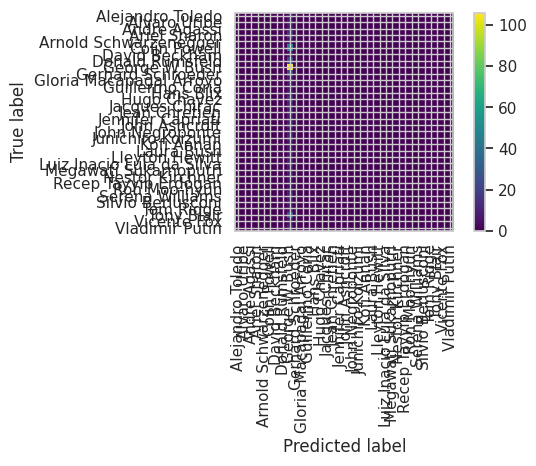

In [9]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
predictions = model.predict(data[test_idx], verbose=0).argmax(axis=1)
print(classification_report(labels[test_idx], predictions, target_names=class_names, zero_division=0))
ConfusionMatrixDisplay.from_predictions(labels[test_idx], predictions, display_labels=class_names, xticks_rotation=90, include_values=False); plt.tight_layout()

## Visualizations

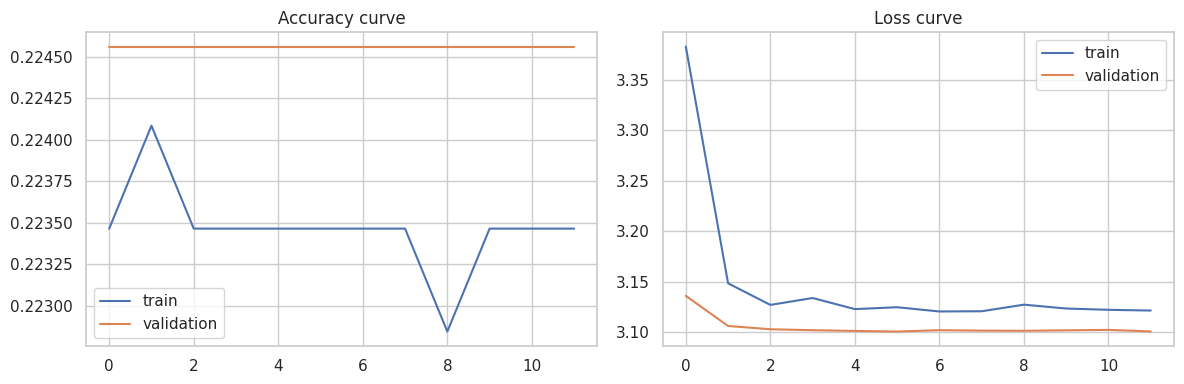

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history["accuracy"], label="train"); axes[0].plot(history.history["val_accuracy"], label="validation"); axes[0].set_title("Accuracy curve"); axes[0].legend()
axes[1].plot(history.history["loss"], label="train"); axes[1].plot(history.history["val_loss"], label="validation"); axes[1].set_title("Loss curve"); axes[1].legend(); plt.tight_layout()

## Prediction Examples

In [11]:
example_indices = test_idx[:8]
probs = model.predict(data[example_indices], verbose=0)
display(pd.DataFrame({"actual": labels[example_indices], "prediction": probs.argmax(axis=1) if probs.shape[1] > 1 else (probs.ravel() > .5).astype(int)}))

,actual,prediction
0,21,8
1,5,8
2,10,8
3,8,8
4,9,8
5,19,8
6,3,8
7,4,8


## Discussion
Results are sensitive to dataset size and class composition. A production system requires external validation, calibration, and error review across relevant subgroups.

## Conclusion
The CNN is trained from scratch with augmentation and held-out evaluation; visual diagnostics make both learning behavior and errors inspectable.